# 7.1 Can you explain a map prediction as a sequence of decisions?

**Objectives:** fit a decision-tree classifier; read its splits; trace a prediction; control tree complexity; compare with a majority-class baseline on held-out geography.

**Prerequisites:** Python arrays/DataFrames and basic plotting. No deep learning required; this can be taught before the embedding lessons. **Time:** 75-90 minutes. **Setup:** existing course `requirements.txt`, no downloads or credentials.

**Data:** synthetic sites, spectral-index-like features and invented cover classes. Coordinates are local teaching coordinates in kilometres, not a real location or georeferenced survey. Labels are constructed from a toy rule with noise; scores demonstrate mechanics, not environmental model performance.

Predict - run - explain - change one thing.

## Before you run

A classification tree learns questions such as “NDVI ≤ 0.42?” Each split sends a row left or right; a leaf predicts a class. With the default Gini criterion, training greedily seeks splits that reduce weighted class impurity. For class proportions p, Gini impurity is `1 - sum(p²)`: zero means a pure node.

`max_depth` limits the number of decisions along a path. `min_samples_leaf` prevents tiny leaves. An unrestricted tree can memorize noisy labels. Tree splits do not require feature standardization, but valid inputs, independent labels and sensible evaluation still matter.

**Prediction:** which will score better on training data, a shallow tree or an unrestricted tree? Does that guarantee better predictions elsewhere?

Primary reference: [scikit-learn DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report, ConfusionMatrixDisplay
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'course.py').exists())
OUT = ROOT/'data'/'generated'/'decision_trees'
OUT.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(42)
n = 1200
sites = pd.DataFrame({'site_id': [f's{i:04d}' for i in range(n)],
                      'x_km': rng.uniform(0, 100, n), 'y_km': rng.uniform(0, 100, n)})
sites['ndvi'] = np.clip(0.25 + 0.004 * sites.x_km + rng.normal(0, 0.2, n), 0, 0.95)
sites['moisture_index'] = np.clip(0.5 + 0.2 * np.sin(sites.y_km / 15) + rng.normal(0, 0.2, n), 0, 1)
sites['slope_deg'] = rng.uniform(0, 40, n)
sites['cover'] = np.where(sites.ndvi < 0.35, 'sparse',
                         np.where((sites.moisture_index > 0.55) & (sites.slope_deg < 18),
                                  'wet vegetation', 'other vegetation'))
# Deliberately imperfect labels. Real labels must be obtained independently of predictor rules.
noisy = rng.random(n) < 0.10
sites.loc[noisy, 'cover'] = rng.choice(['sparse', 'wet vegetation', 'other vegetation'], noisy.sum())
FEATURES = ['ndvi', 'moisture_index', 'slope_deg']
X, y = sites[FEATURES], sites.cover
assert sites.site_id.is_unique and np.isfinite(X.to_numpy()).all()
display(sites.head())

,site_id,x_km,y_km,ndvi,moisture_index,slope_deg,cover
0,s0000,77.395605,56.642065,0.689891,0.232902,17.701104,other vegetation
1,s0001,43.887844,55.090877,0.549872,0.161761,25.413370,other vegetation
2,s0002,85.859792,82.854692,0.585989,0.569044,17.336790,wet vegetation
3,s0003,69.736803,71.053277,0.568458,0.000000,9.781463,wet vegetation
4,s0004,9.417735,2.657776,0.050634,0.720623,27.835151,other vegetation


## Reserve geography before choosing the model

Use western sites for training, a central strip for validation, and eastern sites for final testing. Select complexity using validation only; inspect the test results once the choice is fixed. Coordinates and site IDs are not predictors here.

This split asks about transfer eastward within the toy domain. Adjacent partitions have no buffer; real spatial autocorrelation may require buffers or grouped cross-validation. One split is not a complete estimate of transfer uncertainty.

Partition sizes: {'train': 715, 'validation': 245, 'test': 240}


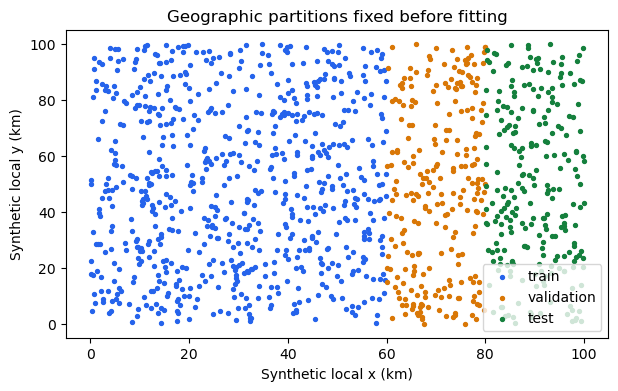

In [10]:
train = sites.x_km < 60
validation = (sites.x_km >= 60) & (sites.x_km < 80)
test = sites.x_km >= 80
assert np.all(train.astype(int) + validation.astype(int) + test.astype(int) == 1)
assert sites.loc[train, 'x_km'].max() < sites.loc[validation, 'x_km'].min()
assert sites.loc[validation, 'x_km'].max() < sites.loc[test, 'x_km'].min()
for mask in [train, validation, test]:
    assert set(y[mask]) == set(y), 'Each teaching partition must contain every class.'
print('Partition sizes:', {name: int(mask.sum()) for name, mask in
                           [('train', train), ('validation', validation), ('test', test)]})
fig, ax = plt.subplots(figsize=(7, 4))
for name, mask, color in [('train', train, '#2563eb'), ('validation', validation, '#d97706'), ('test', test, '#15803d')]:
    ax.scatter(sites.loc[mask, 'x_km'], sites.loc[mask, 'y_km'], s=8, label=name, color=color)
ax.set(xlabel='Synthetic local x (km)', ylabel='Synthetic local y (km)', title='Geographic partitions fixed before fitting')
ax.legend(); plt.show()

## Fit and draw a small tree

This two-level tree is for learning how the algorithm works. It may be too simple to express the full toy rule. At a split, take the left branch for ≤ and the right for >. Node sample counts refer to training rows. Leaf class proportions are not automatically calibrated confidence for new places.

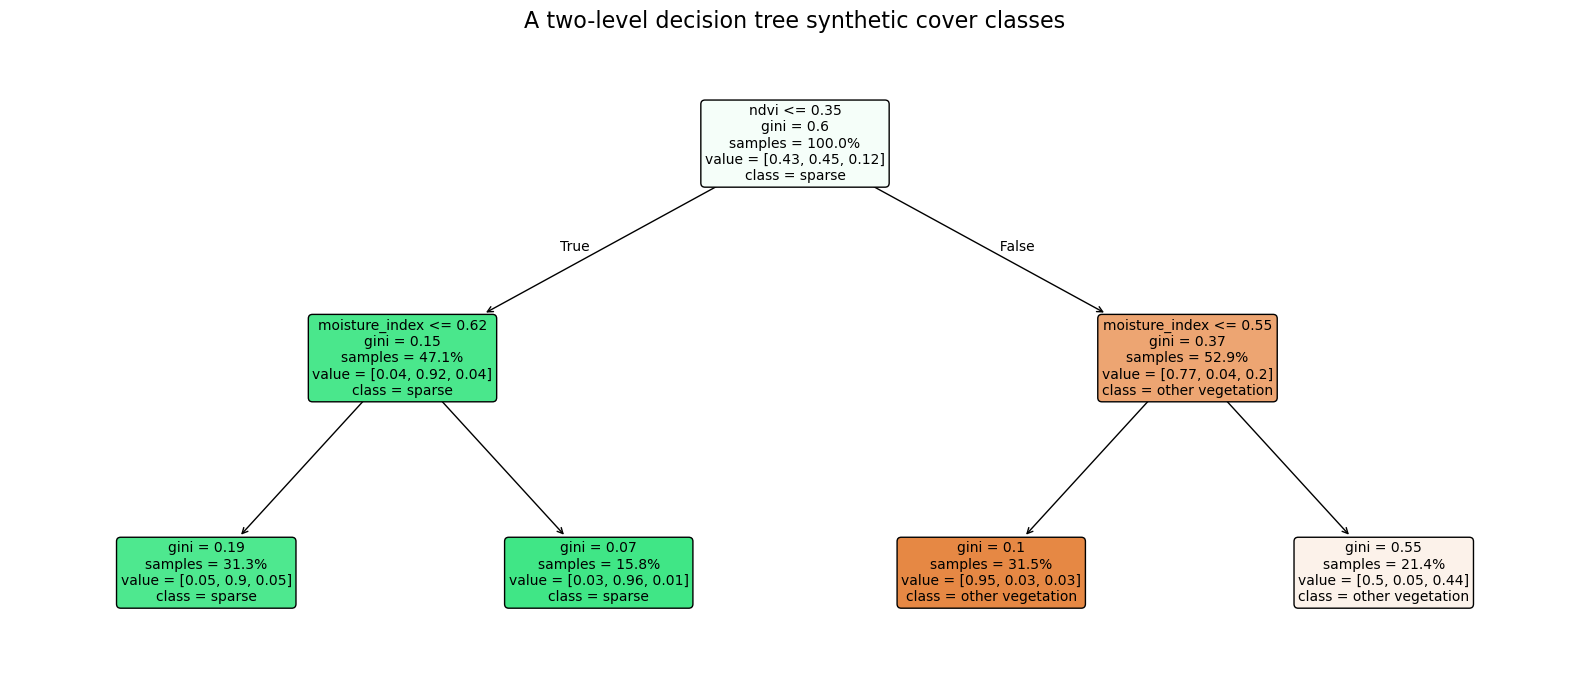

In [11]:
small_tree = DecisionTreeClassifier(max_depth=2, min_samples_leaf=10, random_state=42)
small_tree.fit(X[train], y[train])
fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(small_tree, feature_names=FEATURES, class_names=small_tree.classes_.tolist(),
          filled=True, rounded=True, proportion=True, precision=2, fontsize=10, ax=ax)
ax.set_title('A two-level decision tree synthetic cover classes', fontsize=16)
fig.tight_layout()
fig.savefig(OUT/'decision_tree.png', dpi=140, bbox_inches='tight')
plt.show()

## Trace one prediction yourself

Choose a validation row and predict its route before running this cell. We inspect the model's actual thresholds rather than copying rounded values from the plot. The branch at equality goes left.

In [12]:
row = X[validation].iloc[[0]]
node = 0
structure = small_tree.tree_
while structure.children_left[node] != structure.children_right[node]:
    feature = FEATURES[structure.feature[node]]
    cutoff = structure.threshold[node]
    value = float(row.iloc[0][feature])
    go_left = value <= cutoff
    print(f'{feature}={value:.4f} <= {cutoff:.4f}? {go_left}')
    node = structure.children_left[node] if go_left else structure.children_right[node]
prediction = small_tree.classes_[np.argmax(structure.value[node][0])]
assert prediction == small_tree.predict(row)[0]
print('Leaf:', node, '| predicted:', prediction, '| recorded label:', y.loc[row.index[0]])
display(row)

ndvi=0.6899 <= 0.3500? False
moisture_index=0.2329 <= 0.5548? True
Leaf: 5 | predicted: other vegetation | recorded label: other vegetation


,ndvi,moisture_index,slope_deg
0,0.689891,0.232902,17.701104


## Select complexity using validation

Balanced accuracy averages class recall, giving each class equal weight despite different frequencies. Compare training and validation scores; training success alone is not enough. Include an unrestricted tree to expose memorization. Ties favor the first candidate, with shallow candidates ordered first.

We deliberately keep the original training partition for the final model so the comparison is easy to follow. Another defensible protocol would refit on training plus validation after fixing hyperparameters, then test once.

In [13]:
settings = [(1, 10), (2, 10), (3, 10), (5, 10), (8, 10), (None, 1)]
models, records = [], []
for depth, leaf_size in settings:
    model = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf_size, random_state=42)
    model.fit(X[train], y[train])
    models.append(model)
    records.append(dict(max_depth=str(depth), min_samples_leaf=leaf_size,
                        leaves=model.get_n_leaves(),
                        train_balanced_accuracy=balanced_accuracy_score(y[train], model.predict(X[train])),
                        validation_balanced_accuracy=balanced_accuracy_score(y[validation], model.predict(X[validation]))))
comparison = pd.DataFrame(records)
selected_index = int(np.argmax(comparison.validation_balanced_accuracy.to_numpy()))
selected = models[selected_index]
display(comparison)
print('Selected parameters:', settings[selected_index])
comparison.to_csv(OUT/'depth_comparison.csv', index=False)
assert selected.n_features_in_ == len(FEATURES)

,max_depth,min_samples_leaf,leaves,train_balanced_accuracy,validation_balanced_accuracy
0,1,10,2,0.636912,0.626215
1,2,10,4,0.636912,0.626215
2,3,10,8,0.884858,0.910768
3,5,10,22,0.884858,0.910768
4,8,10,31,0.884858,0.910768
5,None,1,90,1.000000,0.854090


Selected parameters: (3, 10)


## Evaluate once on held-out eastern sites

The majority-class dummy ignores all predictors. A useful classifier should be compared with such a baseline. Read the confusion matrix by row (recorded label) and column (predicted label). These labels are invented and partly noisy; agreement is not proof of physical truth.

After inspecting these scores, do not tune on this test set and still call it held out. Further model development needs a new evaluation split or a nested evaluation design.

,model,balanced_accuracy
0,majority baseline,0.333333
1,validation-selected tree,0.881704


                  precision    recall  f1-score   support

other vegetation       0.93      0.99      0.96       168
          sparse       1.00      0.80      0.89        25
  wet vegetation       0.98      0.85      0.91        47

        accuracy                           0.95       240
       macro avg       0.97      0.88      0.92       240
    weighted avg       0.95      0.95      0.94       240



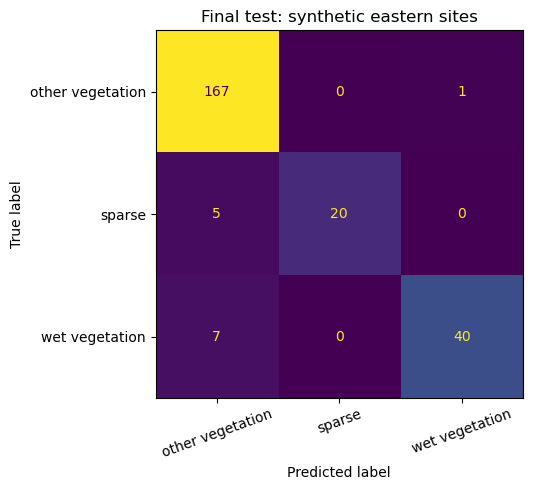

In [14]:
baseline = DummyClassifier(strategy='most_frequent').fit(X[train], y[train])
test_prediction = selected.predict(X[test])
final_scores = pd.DataFrame([
    dict(model='majority baseline', balanced_accuracy=balanced_accuracy_score(y[test], baseline.predict(X[test]))),
    dict(model='validation-selected tree', balanced_accuracy=balanced_accuracy_score(y[test], test_prediction))
])
display(final_scores)
print(classification_report(y[test], test_prediction, labels=selected.classes_, zero_division=0))
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y[test], test_prediction, labels=selected.classes_,
                                       xticks_rotation=20, colorbar=False, ax=ax)
ax.set_title('Final test: synthetic eastern sites'); fig.tight_layout(); plt.show()
results = sites.loc[test, ['site_id', 'x_km', 'y_km', 'cover']].copy()
results['prediction'] = test_prediction
results['correct'] = results.cover == results.prediction
results.to_csv(OUT/'test_predictions.csv', index=False)
final_scores.to_csv(OUT/'test_metrics.csv', index=False)
assert len(results) == int(test.sum()) and final_scores.balanced_accuracy.between(0, 1).all()

## Map mistakes and explain one

Map held-out predictions alongside the recorded labels, using the same category colors. Error locations can suggest follow-up questions; this small synthetic example cannot identify a real environmental cause.

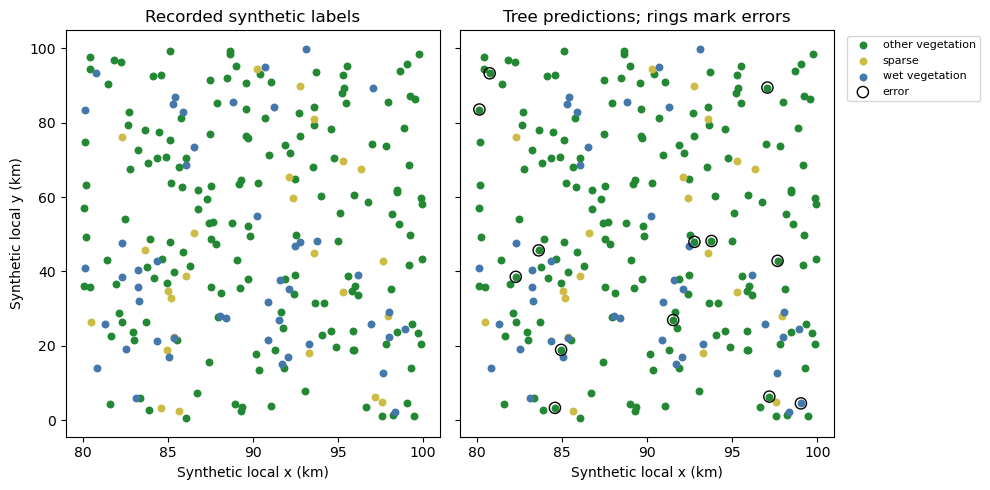

In [15]:
labels = selected.classes_.tolist()
colors = dict(zip(labels, ['#228833', '#ccbb44', '#4477aa']))
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
for ax, column, title in zip(axes, ['cover', 'prediction'], ['Recorded synthetic labels', 'Tree predictions; rings mark errors']):
    for label in labels:
        subset = results[results[column] == label]
        ax.scatter(subset.x_km, subset.y_km, color=colors[label], label=label, s=22)
    ax.set(title=title, xlabel='Synthetic local x (km)', xlim=(79, 101))
mistakes = results[~results.correct]
axes[1].scatter(mistakes.x_km, mistakes.y_km, facecolors='none', edgecolors='black', s=65, label='error')
axes[0].set_ylabel('Synthetic local y (km)')
axes[1].legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
fig.tight_layout(); fig.savefig(OUT/'prediction_map.png', dpi=140, bbox_inches='tight'); plt.show()

## Your independent challenge

1. Before revisiting any test results, propose a new experiment: remove one predictor, change `min_samples_leaf`, or change the label-noise rate. State what you expect and why.
2. Run the experiment using training and validation only. Save a comparison table and explain the effect on overfitting. If using a new random seed, rebuild the fixture and check class coverage.
3. Trace one validation prediction through the tree and explain each branch in plain language. A wrong prediction can be more informative than a correct one.
4. Explain how you would obtain real cover labels and separate training locations from evaluation locations. Do not use the same NDVI rule as both label maker and claimed independent ground truth.

**Submit:** a tree figure, a traced prediction, a train/validation comparison, and a 100-150 word interpretation. For a genuinely new final evaluation, reserve new sites before experimenting; do not repeatedly optimize the existing eastern test scores.

In [16]:
# Your independent experiment here. Keep test data out of model selection.

<details><summary>Solution guidance - open after trying</summary>

Copy the fitting loop and change just one factor, keeping the same training and validation rows for a fair comparison. Larger leaves restrict memorization but can miss minority patterns. Removing moisture or slope makes the constructed wet-vegetation rule harder to recover; removing NDVI removes the strongest direct signal for the sparse class. An unrestricted tree may fit noisy labels very well and still generalize worse. Use the `tree_` traversal above to trace thresholds, remembering that the plot rounds them. These are learned associations, not causal mechanisms.

</details>

## Check yourself and rubric

Why is the test set unavailable during model selection? Why might raw accuracy conceal poor minority-class performance? Why can an easy-to-read tree still be wrong?

| Criterion | Points | Evidence |
|---|---:|---|
| Implementation and split integrity | 2 | Reproducible fit; distinct train/validation/test geography |
| Model interpretation | 3 | Correct traced path and explanation of leaf prediction |
| Independent experiment | 3 | One changed factor, fair comparison, overfitting interpretation |
| Communication | 2 | Labeled outputs; synthetic disclosure; limitations and real-label plan |

**Mastery target:** 8/10 with no test-driven model selection. The highest score is not the goal; justified evaluation is.

## Transfer to real data

Use independently labeled sites with provenance, dates, CRS and sampling notes. Extract contemporaneous raster predictors with appropriate spatial support. Account for nodata and fit any imputation on training data only. Split by meaningful geographic groups, considering buffers and time. Tune on grouped validation data and compare against a dummy baseline on held-out sites. Report class-specific errors and sampling limitations; do not infer causation from splits or feature importance.

## Educator note

Suggested session: 10 minutes for predictions and concepts, 20 for fitting/plotting, 15 for tracing a path, 15 for validation and test interpretation, and 30 for the independent challenge and peer review. For a short Director demonstration, draw the two-level tree and invite the audience to follow one row to its leaf.

## Primary references

- [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
- [Plotting trees](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html)
- [Inspecting tree structure](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html)